In [2]:
#imports
import pandas as pd
from generate_schedule import generate_schedule
from sim_season import simulate_season
from random_fpi import make_random_fpi
from playoffs import playoff_field
from collections import Counter
from real_nfl_schedule import build_real_season_dfs,real_schedule_df
import matplotlib.pyplot as plt
from simulate_playoffs import simulate_playoffs
import nflreadpy as nfl
import numpy as np
from scipy.stats import linregress

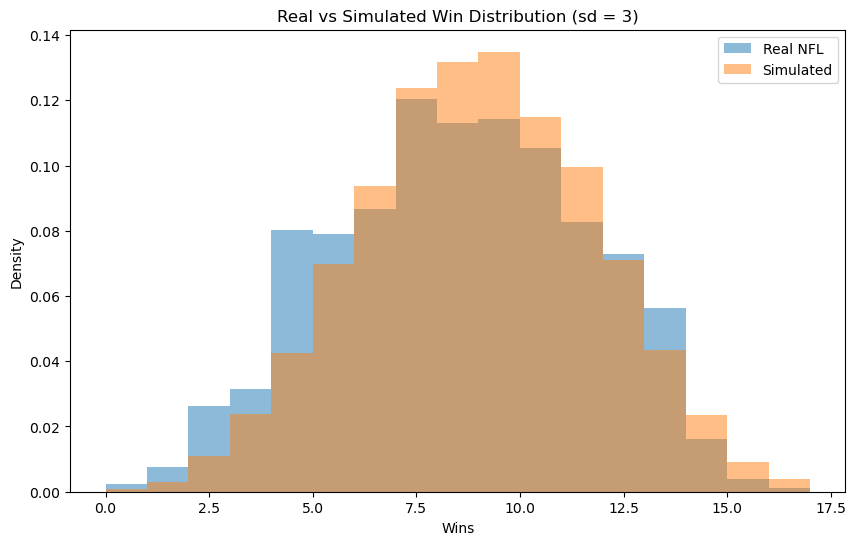

In [33]:
from real_nfl_schedule import build_real_season_dfs
import matplotlib.pyplot as plt

real_wins = []

for year in range(1990, 2024):
    results_df, standings_df = build_real_season_dfs(year)
    
    # assuming column is "Wins"
    real_wins.extend(standings_df["Wins"].values)

sim_wins = []

n_sims = 1000  # bump this if you want smoother results

df = pd.read_csv("FPI-1-11-26.csv")

for sim_seed in range(1, n_sims + 1):
    df_seeded = make_random_fpi(df, mean=0.16, std=3, seed=sim_seed)
    schedule_df = generate_schedule(df_seeded, seed=sim_seed)
    
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)
    
    sim_wins.extend(standings_df["Wins"].values)


plt.figure(figsize=(10,6))

plt.hist(real_wins, bins=range(0,18), density=True, alpha=0.5, label="Real NFL")
plt.hist(sim_wins, bins=range(0,18), density=True, alpha=0.5, label="Simulated")

plt.legend()
plt.title("Real vs Simulated Win Distribution (sd = 3)")
plt.xlabel("Wins")
plt.ylabel("Density")
plt.show()

Counter({'head to head': 330, 'conference_record': 207, 'common_games': 89, 'division_record': 74, 'strength_of_victory': 43})
Counter({'higher FPI won': 375, 'lower FPI won': 368})


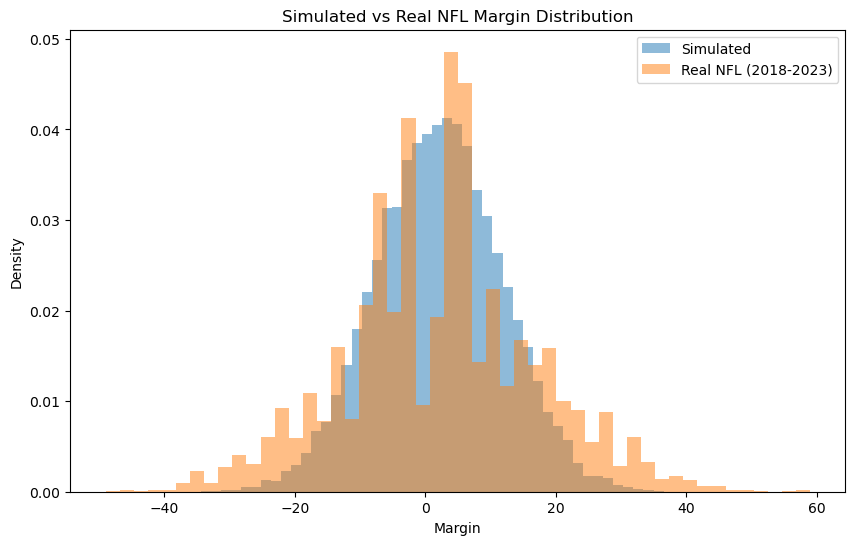

In [41]:
# Better tiebreaking procedures
# 1000 sims on the same FPI/Schedule seed
n = 100

df = pd.read_csv("FPI-1-11-26.csv")
df_seeded = make_random_fpi(df, mean=-0.016, std=3, seed=5)
schedule_df = generate_schedule(df_seeded, seed=1)

tb_counts = Counter()
fpi_counts = Counter()
field_count = Counter()
all_margins = []
for sim_seed in range(1, n + 1):
    results_df, standings_df = simulate_season(df_seeded, schedule_df, seed=sim_seed)

    field, tiebreakers, fpi_winners = playoff_field(standings_df, results_df)

    tb_counts.update(Counter(tiebreakers))
    fpi_counts.update(Counter(fpi_winners))
    field_count.update(Counter(field["Team"]))
    all_margins.extend(results_df["Margin"].values)


print(tb_counts)
print(fpi_counts)


real_margins = []

for year in range(2000, 2024):
    real_results_df, _ = build_real_season_dfs(year)
    real_margins.extend(real_results_df["Margin"].tolist())

plt.figure(figsize=(10, 6))
plt.hist(all_margins, bins=50, alpha=0.5, density=True, label="Simulated")
plt.hist(real_margins, bins=50, alpha=0.5, density=True, label="Real NFL (2018-2023)")
plt.title("Simulated vs Real NFL Margin Distribution")
plt.xlabel("Margin")
plt.ylabel("Density")
plt.legend()
plt.show()

In [43]:
abs_margins = np.abs(all_margins)

for p in [80, 85, 90, 95]:
    print(f"{p}th percentile:", np.percentile(abs_margins, p))


80th percentile: 12.657637107059838
85th percentile: 14.28325521016297
90th percentile: 16.267514484643378
95th percentile: 19.391814767704556
7.899598070826196
7.893869030316452
